# Lab 11

In this lab, as in others, some creative interpretation was applied. 

Used libraries:

In [1]:
import nidaqmx
import time

import numpy as np
import numpy.typing
from typing import Tuple

import matplotlib.pyplot as plt
from nidaqmx.constants import AcquisitionType, ProductCategory
from nidaqmx.constants import TerminalConfiguration
from nidaqmx.constants import AcquisitionType, READ_ALL_AVAILABLE, LineGrouping


import scipy as sp



## Task 1 ish


In [2]:
device_name = "/Dev5"

In [3]:
ao_data = np.concatenate((
  np.zeros(1000),np.ones(1000)*5), axis=0)
sps = 100000.  # samples per second
ao_times = np.arange(len(ao_data)) / sps

In [4]:
total_read = 0
sps = 100000                 
n_samps = len(ao_data)

with nidaqmx.Task() as aitask, nidaqmx.Task() as aotask, nidaqmx.Task() as trigtask:
    # AI: single channel (ai0), finite, same length as AO
    aitask.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5, max_val=5
    )
    aitask.timing.cfg_samp_clk_timing(
        sps,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=n_samps
    )
    aitask.triggers.start_trigger.cfg_dig_edge_start_trig(device_name + "/PFI4")

    # AO: single channel (ao0), finite, triggered by same line
    aotask.ao_channels.add_ao_voltage_chan(device_name + "/ao0")
    aotask.timing.cfg_samp_clk_timing(
        sps,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=n_samps
    )
    aotask.triggers.start_trigger.cfg_dig_edge_start_trig(device_name + "/PFI4")

    # Single digital line to issue the trigger
    trigtask.do_channels.add_do_chan(f"{device_name}/port1/line0")

    # Queue AO data but don't autostart
    aotask.write(ao_data, auto_start=False)

    print(f"Actual sampling rate: {aotask.timing.samp_clk_rate:g} S/s")

    # Arm tasks (important for triggered start)
    aitask.start()
    aotask.start()
    trigtask.start()

    # One trigger pulse → one cycle
    trigtask.write(False)
    trigtask.write(True)

    # Single blocking read of the whole record
    read = np.array(aitask.read(number_of_samples_per_channel=n_samps))

    aitask.stop()
    aotask.stop()
    trigtask.stop()

total_read = read.size
print(f"Acquired {total_read} samples on ai0.")



Actual sampling rate: 100000 S/s
Acquired 2000 samples on ai0.


Text(0.5, 0, 'Time [s]')

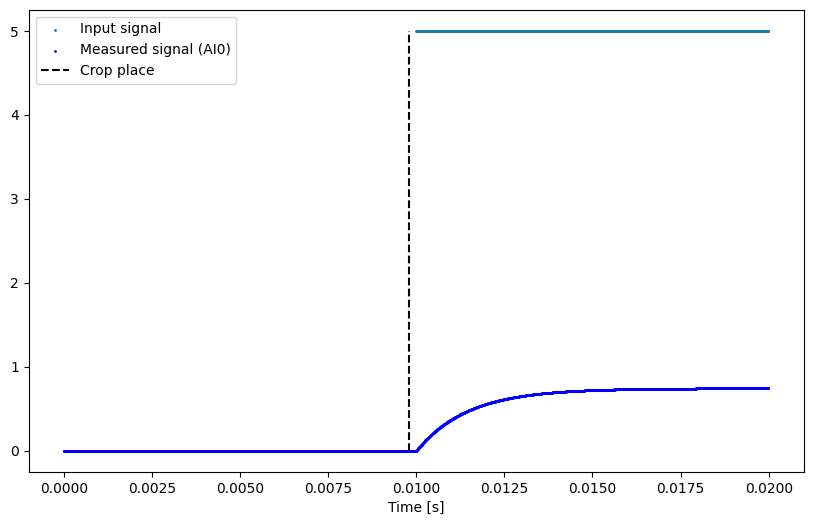

In [5]:
crop_start = len(ao_times)//2-20

fig, ax = plt.subplots(1, figsize=(10,6))
ax.scatter(ao_times, ao_data, s=1, label='Input signal', color='C0')
#ax.plot(ao_times, pr.RC_response(ao_times, ao_data, w), label='RC response', color='C1')
ax.scatter(np.arange(len(read))/sps, read, s=1, label='Measured signal (AI0)', color='blue')
ax.vlines(x=ao_times[crop_start], ymin=0, ymax=5, colors='black', linestyles='dashed', label='Crop place')
ax.legend(loc='upper left')
ax.set_xlabel('Time [s]')


# Task 2


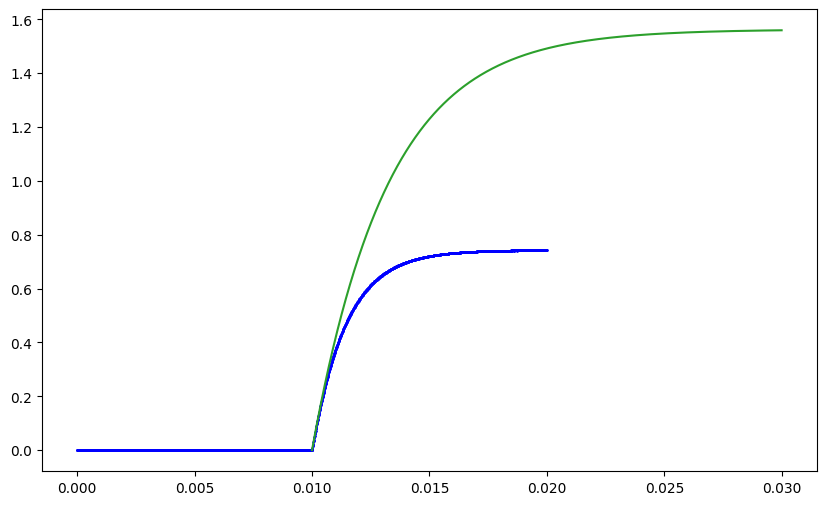

In [6]:
import DE_alg_RRC as pr # provided code
w = [2.2e4, 1.0e4, .47e-6]  # R1, R2, C

Vs = 5.0
def fmodel(x, w):
    global Vs
    x  = np.asarray(x)
    R1 = w[0]
    R2 = w[1]
    C  = w[2]

    alpha = R1/R2+1
    return Vs/alpha*(1-np.exp(-alpha/R1/C*x))

curve = fmodel(ao_times, w)

fig, ax = plt.subplots(1, figsize=(10,6))
ax.plot(ao_times+ao_times[len(ao_times)//2], curve, label='Initial curve', color='C2')
ax.scatter(ao_times, read, s=1, label='Measured signal (AI0)', color='blue')

# Task 3?

As there is a need for showing live resistance, it is diffucult to do in jupyter, so I'll do it by modifying provided code in a .py file

c:\Users\leoni\Projects\Masters Semester 1\Data Acquisition and Signal Processing (LOTI.05.052)\Labs\Lab 11\DE_alg_RRC.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = R1/R2+1
c:\Users\leoni\Projects\Masters Semester 1\Data Acquisition and Signal Processing (LOTI.05.052)\Labs\Lab 11\DE_alg_RRC.py:49: RuntimeWarning: invalid value encountered in multiply
  return Vs/alpha*(1-np.exp(-alpha/R1/C*x))


(150, 5000)
R2:  3931.1801727696093  C:  1e-06


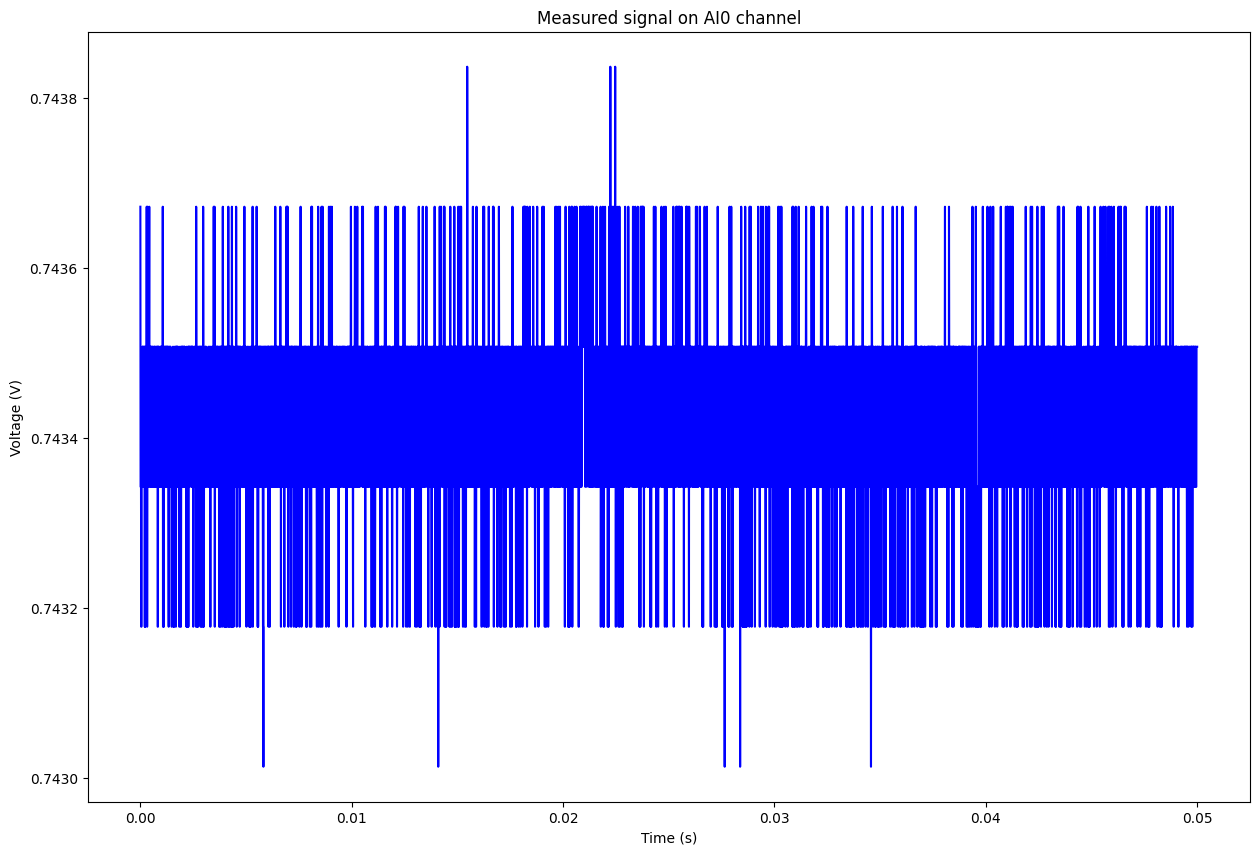

(150, 5000)
R2:  6357.107705514808  C:  1e-06


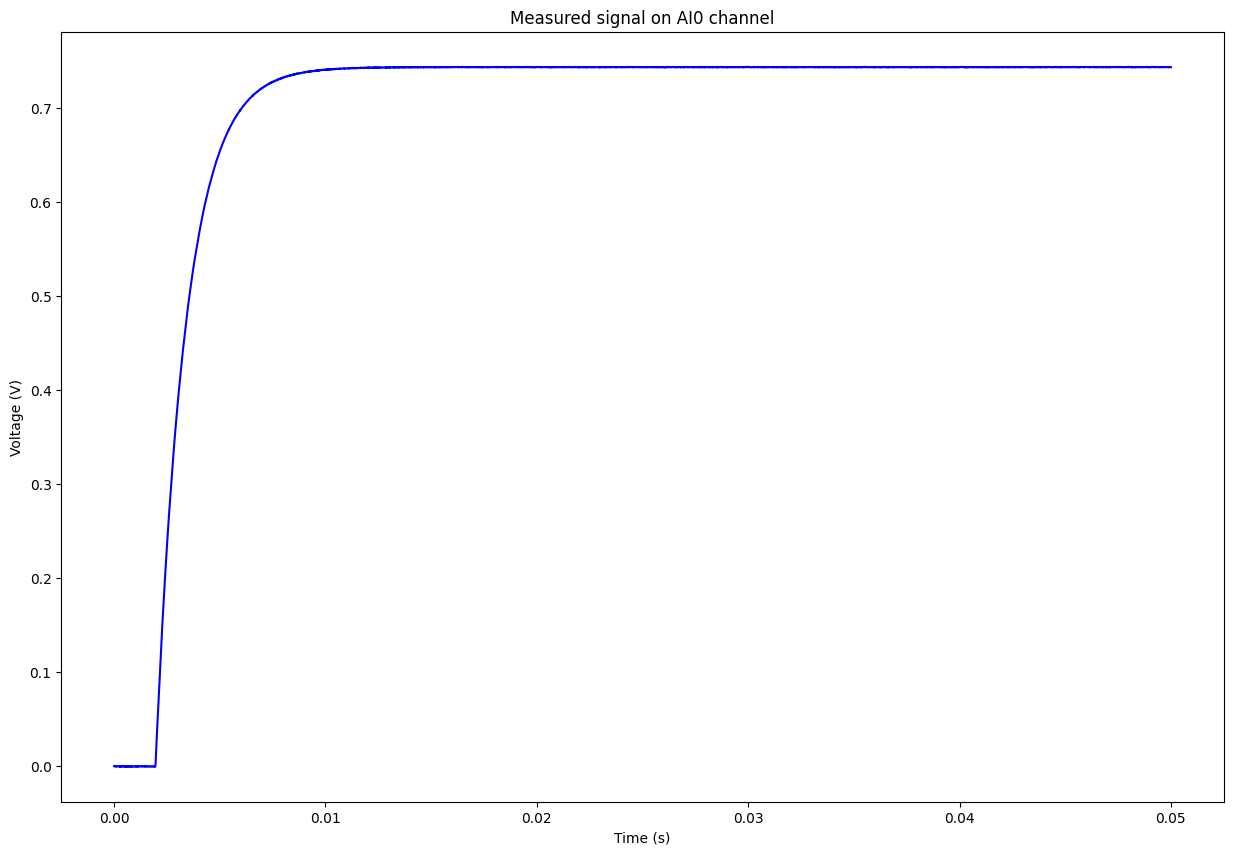

KeyboardInterrupt: 

In [7]:
import nidaqmx
from nidaqmx import stream_readers
from nidaqmx.constants import TerminalConfiguration

import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import DE_alg_RRC

DEV = "Dev5"
TRIG_SRC = "PFI0"
AI_CH = ["ai0", "ai1"]
AO_CH = ["ao0"]
T_TO_CHRG = 0.05
SAMPLING_RATE = 100000
PRETRIGGER_SAMPLES_RATIO = 0.01
NO_OF_SAMPLES = int(T_TO_CHRG * SAMPLING_RATE)
AO_VS = 5

samples_buf = None #Initialize a buffer to hold the acquired samples in.

### Initializes the DAQ device.
### Parameters:
###     dev: DAQ device name (String)
###     ai_channels: The analouge channels to use in the analouge in task (1D list of strings)
###     ao_channels: The analouge channels to use in the analouge out task (1D list of strings)
###     trig_src: The trigger source pin which triggers the ai_task. (String)
###     no_of_samples: The total number of samples to acquire (Integer)
###     sampling_rate: The sampling rate to use for the task. (Float)
###
### Returns:
###     ai_task: DAQ device task that measures ai_channels
###     ao_task: DAQ device task that writes to ao_channels
###

def initialize_device(dev, ai_channels, ao_channels, trig_src, no_of_samples, sampling_rate):
    global samples_buf

    # Initialize buffer for samples. This creates a 2D numpy array: a row for each of the input channels, each row holds no_of_samples data points.
    samples_buf = np.zeros((len(ai_channels), no_of_samples))

    ai_task = nidaqmx.Task("AI TASK") # Create a task, named "AI TASK"

    # Iterate over all input channels and add them to the ai_task
    for i in range(len(ai_channels)):
        ai_task.ai_channels.add_ai_voltage_chan(dev + "/" + ai_channels[i], ai_channels[i], terminal_config = TerminalConfiguration.RSE) # Voltage channel must be in the form <Device name>/<Analouge in channel>. More info: https://nidaqmx-python.readthedocs.io/en/latest/_modules/nidaqmx/_task_modules/ai_channel_collection.html#AIChannelCollection.add_ai_voltage_chan

    ai_task.timing.cfg_samp_clk_timing(sampling_rate, samps_per_chan=no_of_samples) # Set timing for task.

    ai_task.in_stream.auto_start = False # Forces to explicitly start task.

    reader = stream_readers.AnalogMultiChannelReader(ai_task.in_stream) # Creates a reader instance

    ao_task = nidaqmx.Task("AO TASK")
    for ao_channel in ao_channels:
        ao_task.ao_channels.add_ao_voltage_chan(dev + "/" + ao_channel, ao_channel)

    return ai_task, ao_task, reader

### Starts the tasks: Generates a pulse using ao_task and collects the samples into samples_buf using ai_task.
### Parameters:
###     ai_task: The ai_task to use for sample collection (nidaqmx.task)
###     ao_task: The ao_task to use for pulse generation (nidaqmx.task)
###     reader: Reader instance to use for sample reading (nidaqmx.stream_readers.AnalogMultiChannelReader)
###     ao_Vs: The voltage (in volts) to write using ao_task (float)
###     t_to_dischrg: The time to wait fater reseting output to 0V for the system to discharge (float)
def start_tasks(ai_task, ao_task, reader, ao_Vs, t_to_dischrg=1):
    global samples_buf

    ai_task.start()

    ao_task.start()
    ao_task.write(ao_Vs)

    reader.read_many_sample(samples_buf, nidaqmx.constants.READ_ALL_AVAILABLE)
    ai_task.stop()
    time.sleep(t_to_dischrg)
    ao_task.write(0)
    time.sleep(t_to_dischrg)
    ao_task.stop()

### Generates a matplotlib graph on a subplot and places it on the figure.
### Paramteters:
###     ydata: The data to plot. Each row plots a single line. (2D numpy array of floats)
###     xdata: X-axis values (1D numpy array of integers)
###     title: Title to use for the graph (String)
###     xlabel: Label for the x-axis (String)
###     ylabel: Label for the y-axis (String)
###     data_labels: Labels to use for each of the lines given in ydata.
###     plot_shape: The shape to use for the fiugre. This is the shape of the whole plottable area, given in number of rows and columns (2-tuple of integers)
###     subplot_colspan: Specifies how many columns the given subplot spans in plot_shape units (Integer)
###     subplot_rowspan: Specifies how many rows the given subplot spans in plot_shape units (Integer)
### Returns:
###     ax: The axis of the current subplot. (numpy.axes.SubplotBase)


ai_task, ao_task, reader = initialize_device(DEV, AI_CH, AO_CH, TRIG_SRC, NO_OF_SAMPLES, sampling_rate = SAMPLING_RATE) # Initialize the DAQ device
while 1:
    start_tasks(ai_task, ao_task, reader, AO_VS, T_TO_CHRG) # Start the tasks
    # Generate x-axis values: a numpy array with whole numbers in the range of [0, <length of samples buffer>)
    # divided by sampling rate gives us the point in time each sample was measured relative to the time the first sample was measured.
    xdata = (np.linspace(0, samples_buf.shape[1], samples_buf.shape[1]))/SAMPLING_RATE

    capacitor_chraging_curve = samples_buf[0] # Assume that the first measurment in the buffer is the measurment of voltage on the capacitor.

    # Differential evolution parameters
    popsize = 15
    its = 150
    mut = 0.3
    crossp=0.5
    bounds = [(22E3, 22E3), (0, 100000), (1E-6, 1E-6)]

    de_result = DE_alg_RRC.main(xdata, capacitor_chraging_curve, [popsize, its, mut, crossp, bounds, AO_VS]) # Run differential evolution

    # Extract the results of differential evolution
    params = de_result[0]
    # Each row of params contains values for R1, R2 and C. To plot the evolution of each of the values,
    # we transpose the array containing these results.
    param_iterations = params.T
    R1 = np.array([param_iterations[0]])
    R2 = np.array([param_iterations[1]])
    C = np.array([param_iterations[2]])
    err = np.array([de_result[1]])
    opt_curves = de_result[2]
    opt_curve = np.array([opt_curves[-1]]) # Select the last iteration of optimized curve to plot.

    curve_plot_y = np.zeros((samples_buf.shape[0] + 1, samples_buf.shape[1])) # Initialize a numpy array for plotting the optimized curve generated with DE and the actually measured data on the same plot.

    # Assign the elements from the measurement buffer to buffer created in the previous step.
    for i in range(samples_buf.shape[0]):
        curve_plot_y[i] = samples_buf[i]
    curve_plot_y[-1] = opt_curve # Append the optimized curve to the buffer to be plotted

    print('R2: ', R2[-1][-1], ' C: ', C[-1][-1])
    # Plot chargeing curve
    fig, axs = plt.subplots(figsize=(15,10))
    axs.plot(xdata, curve_plot_y[0], label='Measured signal (AI0)', color='blue')
    axs.set_title('Measured signal on AI0 channel')
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Voltage (V)')
    plt.show()
    
ai_task.stop()
ao_task.write(0)
ao_task.stop()
ai_task.close()
ao_task.close()

In [ ]:
import nidaqmx
from nidaqmx import stream_readers
from nidaqmx.constants import TerminalConfiguration

import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import DE_alg_RRC

DEV = "Dev5"
TRIG_SRC = "PFI0"
AI_CH = ["ai0", "ai1"]
AO_CH = ["ao0"]
T_TO_CHRG = 0.05
SAMPLING_RATE = 100000
PRETRIGGER_SAMPLES_RATIO = 0.01
NO_OF_SAMPLES = int(T_TO_CHRG * SAMPLING_RATE)
AO_VS = 5

samples_buf = None #Initialize a buffer to hold the acquired samples in.

### Initializes the DAQ device.
### Parameters:
###     dev: DAQ device name (String)
###     ai_channels: The analouge channels to use in the analouge in task (1D list of strings)
###     ao_channels: The analouge channels to use in the analouge out task (1D list of strings)
###     trig_src: The trigger source pin which triggers the ai_task. (String)
###     no_of_samples: The total number of samples to acquire (Integer)
###     sampling_rate: The sampling rate to use for the task. (Float)
###
### Returns:
###     ai_task: DAQ device task that measures ai_channels
###     ao_task: DAQ device task that writes to ao_channels
###

def initialize_device(dev, ai_channels, ao_channels, trig_src, no_of_samples, sampling_rate):
    global samples_buf

    # Initialize buffer for samples. This creates a 2D numpy array: a row for each of the input channels, each row holds no_of_samples data points.
    samples_buf = np.zeros((len(ai_channels), no_of_samples))

    ai_task = nidaqmx.Task("AI TASK") # Create a task, named "AI TASK"

    # Iterate over all input channels and add them to the ai_task
    for i in range(len(ai_channels)):
        ai_task.ai_channels.add_ai_voltage_chan(dev + "/" + ai_channels[i], ai_channels[i], terminal_config = TerminalConfiguration.RSE) # Voltage channel must be in the form <Device name>/<Analouge in channel>. More info: https://nidaqmx-python.readthedocs.io/en/latest/_modules/nidaqmx/_task_modules/ai_channel_collection.html#AIChannelCollection.add_ai_voltage_chan

    ai_task.timing.cfg_samp_clk_timing(sampling_rate, samps_per_chan=no_of_samples) # Set timing for task.

    ai_task.in_stream.auto_start = False # Forces to explicitly start task.

    reader = stream_readers.AnalogMultiChannelReader(ai_task.in_stream) # Creates a reader instance

    ao_task = nidaqmx.Task("AO TASK")
    for ao_channel in ao_channels:
        ao_task.ao_channels.add_ao_voltage_chan(dev + "/" + ao_channel, ao_channel)

    return ai_task, ao_task, reader

### Starts the tasks: Generates a pulse using ao_task and collects the samples into samples_buf using ai_task.
### Parameters:
###     ai_task: The ai_task to use for sample collection (nidaqmx.task)
###     ao_task: The ao_task to use for pulse generation (nidaqmx.task)
###     reader: Reader instance to use for sample reading (nidaqmx.stream_readers.AnalogMultiChannelReader)
###     ao_Vs: The voltage (in volts) to write using ao_task (float)
###     t_to_dischrg: The time to wait fater reseting output to 0V for the system to discharge (float)
def start_tasks(ai_task, ao_task, reader, ao_Vs, t_to_dischrg=1):
    global samples_buf

    ai_task.start()

    ao_task.start()
    ao_task.write(ao_Vs)

    reader.read_many_sample(samples_buf, nidaqmx.constants.READ_ALL_AVAILABLE)
    ai_task.stop()
    print("discharge ", t_to_dischrg)
    time.sleep(t_to_dischrg)
    ao_task.write(0)
    time.sleep(t_to_dischrg)
    ao_task.stop()

### Generates a matplotlib graph on a subplot and places it on the figure.
### Paramteters:
###     ydata: The data to plot. Each row plots a single line. (2D numpy array of floats)
###     xdata: X-axis values (1D numpy array of integers)
###     title: Title to use for the graph (String)
###     xlabel: Label for the x-axis (String)
###     ylabel: Label for the y-axis (String)
###     data_labels: Labels to use for each of the lines given in ydata.
###     plot_shape: The shape to use for the fiugre. This is the shape of the whole plottable area, given in number of rows and columns (2-tuple of integers)
###     subplot_colspan: Specifies how many columns the given subplot spans in plot_shape units (Integer)
###     subplot_rowspan: Specifies how many rows the given subplot spans in plot_shape units (Integer)
### Returns:
###     ax: The axis of the current subplot. (numpy.axes.SubplotBase)
def generate_graph(ydata, xdata=None, title="Graph Title", xlabel="x", ylabel="y", data_labels=None, plot_shape=(1,1), subplot_location=(0,0), subplot_colspan=1, subplot_rowspan=1):

    # Generate default values for X-axis if not given. This creates a numpy array that contains numbers from 0 to the lingth of ydata.
    if xdata is None:
        xdata = np.linspace(0, ydata.shape[1], ydata.shape[1])

    # Generate default values for data_labels if not given.
    if data_labels is None:
        data_labels = []
        for i in range(len(ydata)):
            data_labels.append("line " + str(i))

    # Generate a pandas dataframe for the input data for seaborn lineplot function to use.
    df = pd.DataFrame()
    for i in range(len(ydata)):
        x = xdata
        y = ydata[i]
        legend = np.array([data_labels[i] for j in range(ydata.shape[1])])
        df = pd.concat([pd.DataFrame({xlabel:x, ylabel:y, "Legend":legend}), df])

    # Create a subplot into which the current data will be plotted
    ax = plt.subplot2grid(plot_shape, subplot_location, colspan=subplot_colspan, rowspan=subplot_rowspan)

    # Create a line plot into the previosly created subplot
    sns.lineplot(x=xlabel, y=ylabel, hue="Legend", data=df, ax=ax)

    #Set plot parameters
    ax.set_title(title)
    ax.xlabel=xlabel
    ax.ylabel=ylabel
    ax.legend()
    ax.minorticks_on()

    # Set colors of the plot
    ax.grid(visible=True, which='major', linestyle='-', color="#005600")
    ax.grid(visible=True, which='minor', linestyle='--', alpha=0.8, color="#005600")
    ax.set_facecolor("#222222")

    return ax

ai_task, ao_task, reader = initialize_device(DEV, AI_CH, AO_CH, TRIG_SRC, NO_OF_SAMPLES, sampling_rate = SAMPLING_RATE) # Initialize the DAQ device
try:
    start_tasks(ai_task, ao_task, reader, AO_VS, T_TO_CHRG) # Start the tasks
    # Generate x-axis values: a numpy array with whole numbers in the range of [0, <length of samples buffer>)
    # divided by sampling rate gives us the point in time each sample was measured relative to the time the first sample was measured.
    xdata = (np.linspace(0, samples_buf.shape[1], samples_buf.shape[1]))/SAMPLING_RATE

    capacitor_chraging_curve = samples_buf[0] # Assume that the first measurment in the buffer is the measurment of voltage on the capacitor.

    # Differential evolution parameters
    popsize = 15
    its = 150
    mut = 0.3
    crossp=0.5
    bounds = [(22E3, 22E3), (0, 100000), (1E-6, 1E-6)]

    de_result = DE_alg_RRC.main(xdata, capacitor_chraging_curve, [popsize, its, mut, crossp, bounds, AO_VS]) # Run differential evolution

    # Extract the results of differential evolution
    params = de_result[0]
    # Each row of params contains values for R1, R2 and C. To plot the evolution of each of the values,
    # we transpose the array containing these results.
    param_iterations = params.T
    R1 = np.array([param_iterations[0]])
    R2 = np.array([param_iterations[1]])
    C = np.array([param_iterations[2]])
    err = np.array([de_result[1]])
    opt_curves = de_result[2]
    opt_curve = np.array([opt_curves[-1]]) # Select the last iteration of optimized curve to plot.

    curve_plot_y = np.zeros((samples_buf.shape[0] + 1, samples_buf.shape[1])) # Initialize a numpy array for plotting the optimized curve generated with DE and the actually measured data on the same plot.

    # Assign the elements from the measurement buffer to buffer created in the previous step.
    for i in range(samples_buf.shape[0]):
        curve_plot_y[i] = samples_buf[i]
    curve_plot_y[-1] = opt_curve # Append the optimized curve to the buffer to be plotted

    plot_shape = (14,8)

    # Plot the measured data and the optimized curve.
    graph_title = r"Charging of 1uF Capacitor in parallel with a potentiometer." + '\n' +r"Fs=" + str(SAMPLING_RATE/1000) + "kHz"
    data_labels = ["Voltage on AO0", "Measured voltage on capactior", "Fitted curve"]
    xlabel="Sample number"
    ylabel="Voltage (V)"
    ax1 = generate_graph(curve_plot_y, xdata=xdata, title=graph_title, xlabel=xlabel, ylabel=ylabel, data_labels=data_labels, plot_shape=plot_shape, subplot_colspan=4, subplot_rowspan=4)

    # Plot convergence of DE algorithm.
    graph_title = "Convergence"
    data_labels = ["RMSE"]
    xlabel="Iteration"
    ylabel="RMS Error (V)"
    generate_graph(err, xdata=np.arange(err.shape[1]), title=graph_title, xlabel=xlabel , ylabel=ylabel, data_labels=data_labels, plot_shape=plot_shape, subplot_location=(9,0), subplot_colspan=4, subplot_rowspan=4)

    # Plot the values used for R1 through th curve optimization
    graph_title = "R1"
    data_labels = ["R1"]
    xlabel="Measurment cycle"
    ylabel="Resistance (Ohm)"
    generate_graph(R1, xdata=np.arange(R1.shape[1]), title=graph_title, xlabel=xlabel , ylabel=ylabel, data_labels=data_labels, plot_shape=plot_shape, subplot_location=(0,5), subplot_colspan=4, subplot_rowspan=3)

    # Plot the values used for R2 through th curve optimization
    graph_title = "R2"
    data_labels = ["R1"]
    xlabel="Measurment cycle"
    ylabel="Resistance (Ohm)"
    generate_graph(R2, xdata=np.arange(R2.shape[1]), title=graph_title, xlabel=xlabel , ylabel=ylabel, data_labels=data_labels, plot_shape=plot_shape, subplot_location=(5,5), subplot_colspan=4, subplot_rowspan=3)

    # Plot the values used for C through th curve optimization
    graph_title = "C"
    data_labels = ["C"]
    xlabel="Measurment cycle"
    ylabel="Capacitance (F)"
    generate_graph(C, xdata=np.arange(C.shape[1]), title=graph_title, xlabel=xlabel , ylabel=ylabel, data_labels=data_labels, plot_shape=plot_shape, subplot_location=(10,5), subplot_colspan=4, subplot_rowspan=3)


    # Show the plot.
    plt.tight_layout()
    ax1.get_figure().set_facecolor('#BFBFBF')
    plt.show()
except Exception as e:
    raise e
finally: # Close the created tasks if the proigram exits
    ai_task.stop()
    ao_task.write(0)
    ao_task.stop()
    ai_task.close()
    ao_task.close()


# Tasks

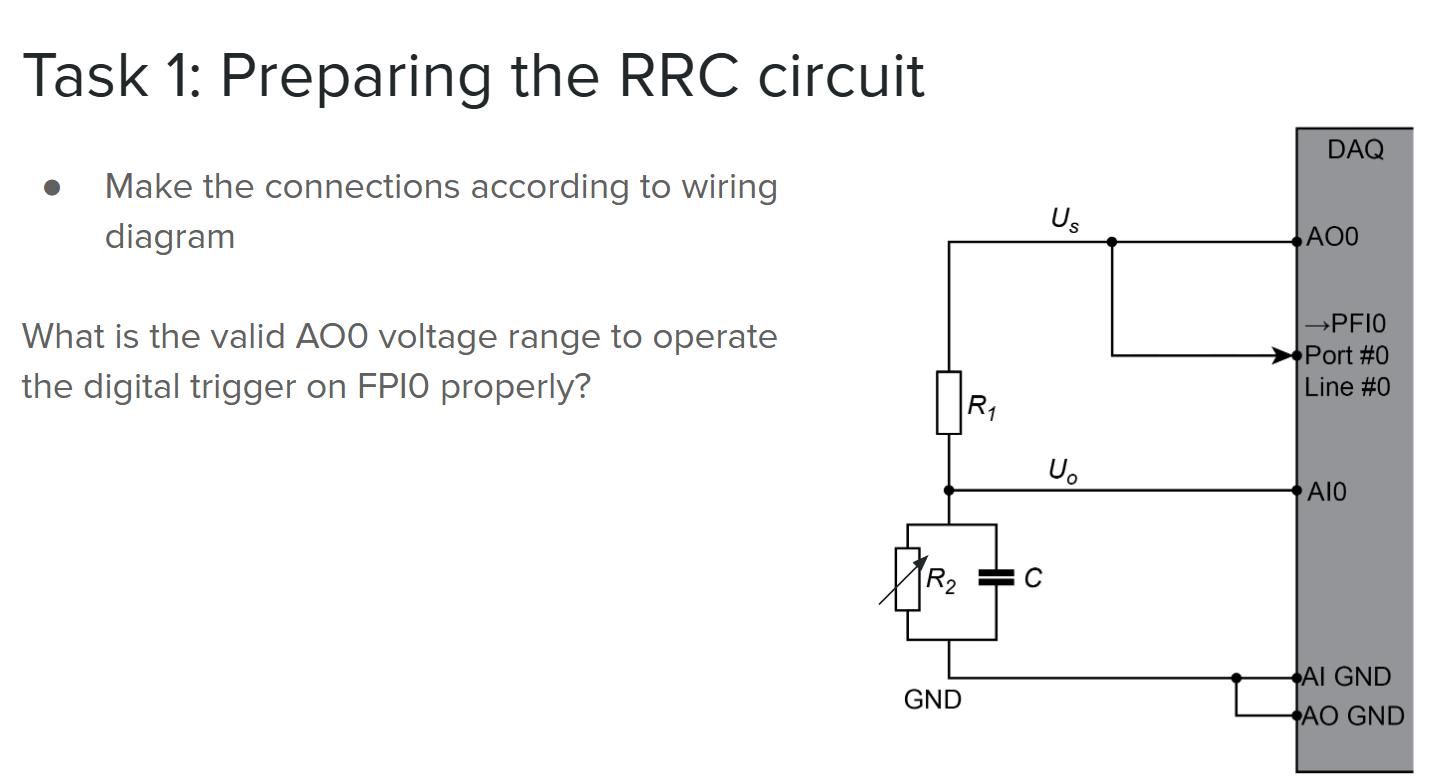

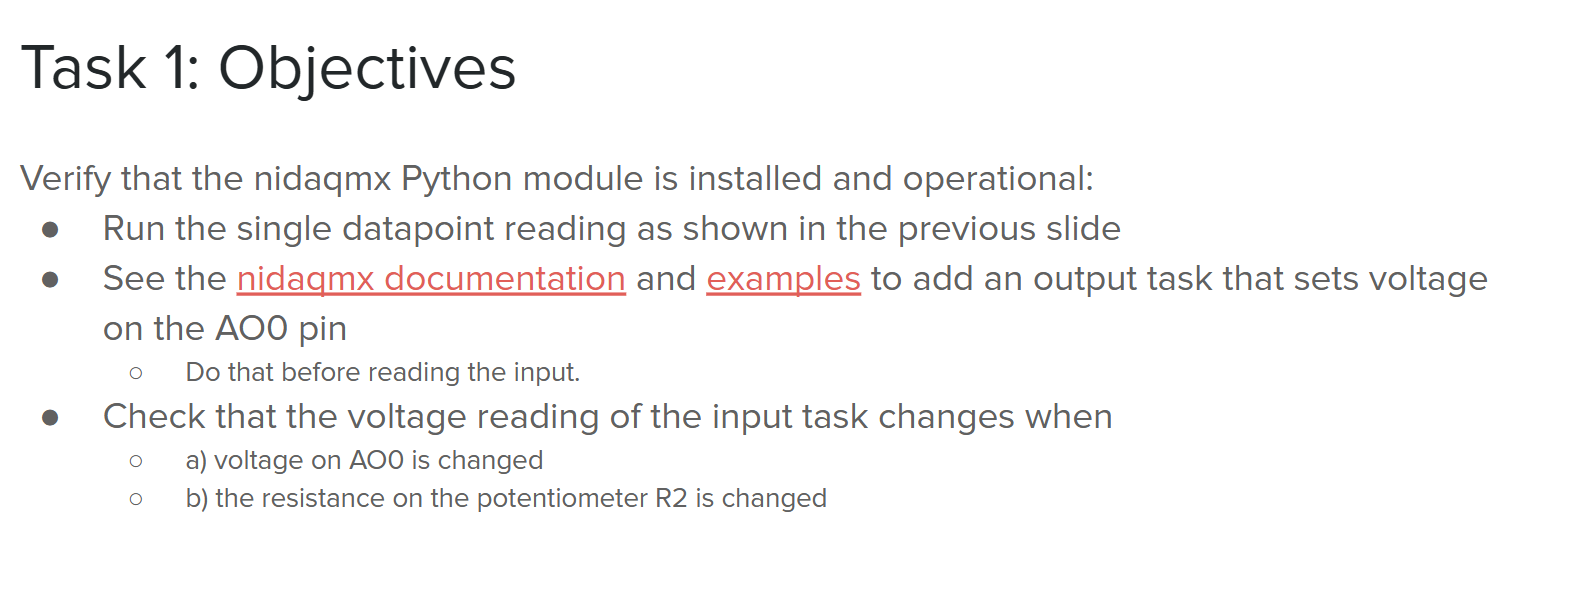

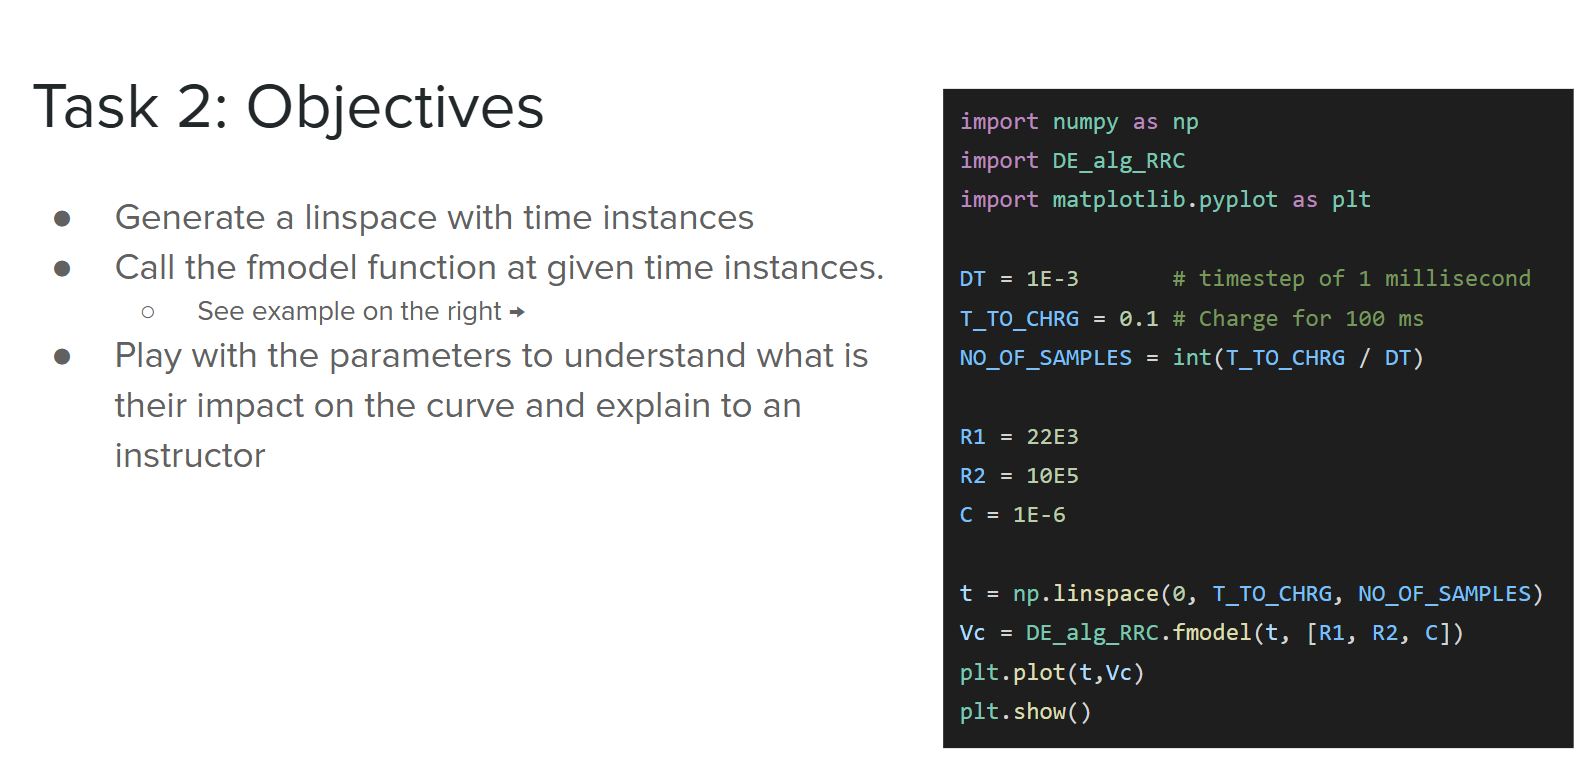

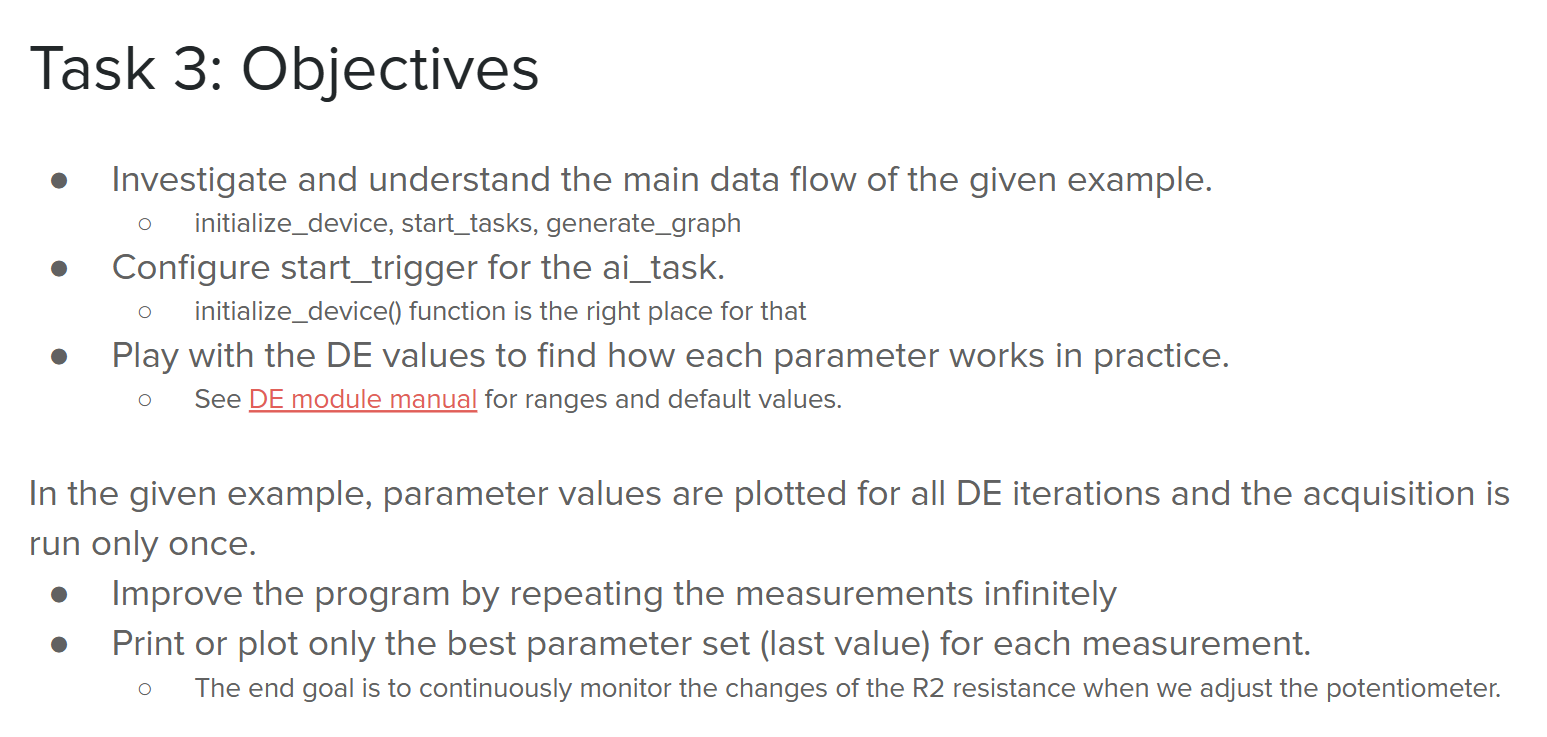